<a href="https://colab.research.google.com/github/VintaBytes/Ciencia-de-datos/blob/main/libros/ciencia-de-datos-con-python/volumen-04/cuadernos/CienciaDeDatos_Tomo3_Cuaderno31.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/></a>

# Capítulo 31 — Comunicar resultados de Machine Learning

En este cuaderno retomaremos explícitamente el ejemplo de **abandono de clientes** utilizado en el capítulo teórico y en cuadernos anteriores. El propósito no será aprender un algoritmo nuevo ni perseguir una métrica más alta, sino transformar un análisis técnico en un informe que otra persona pueda comprender y evaluar.

Construiremos un flujo breve y correcto, y usaremos sus resultados reales para responder las preguntas centrales del capítulo: qué problema se abordó, con qué datos, por qué se eligió ese enfoque, qué significan las métricas, dónde se equivoca el modelo y qué conclusiones pueden sostenerse sin exagerar.


## Objetivos del cuaderno

Al finalizar, deberías poder:

- formular el problema antes de nombrar el algoritmo;
- describir la unidad de análisis, la variable objetivo y el momento de predicción;
- justificar el preprocesamiento, la evaluación y los modelos comparados;
- presentar métricas con su conjunto de procedencia y su interpretación;
- comparar modelos considerando promedio, variabilidad, errores y complejidad;
- mostrar falsos positivos, falsos negativos y diferencias entre subgrupos;
- distinguir predicción, asociación y causalidad;
- escribir una conclusión que incluya alcance, limitaciones y uso previsto;
- adaptar el nivel de detalle a públicos diferentes.


## 1. Importar las herramientas

Usaremos Pandas y NumPy para preparar los datos, Matplotlib para comunicar resultados y `scikit-learn` para construir un flujo de clasificación reproducible.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_recall_curve,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


## 2. Explicar el problema

El informe no debería comenzar con “se entrenó un Random Forest”. Primero debemos aclarar la necesidad.

> **Objetivo:** anticipar qué clientes presentan riesgo de abandonar el servicio durante el mes siguiente, utilizando únicamente información disponible hasta la fecha de corte.

Como la variable objetivo tendrá dos valores —abandono o permanencia—, se trata de una **clasificación binaria**. La clase positiva será el abandono. El resultado se imaginará como una ayuda para priorizar contactos de retención, no como una decisión automática sobre los clientes.

Esta formulación define tres aspectos que a veces quedan implícitos: qué se predice, cuándo se predice y para qué podría usarse la predicción.


## 3. Construir los datos del caso

El dataset será sintético. Esto permite conocer cómo fue generado y evita presentar sus patrones como hechos sobre una empresa o una población real.

Cada fila representa un cliente observado en una fecha de corte mensual. Las variables describen su antigüedad, uso, reclamos, cargo, contrato y canal. `abandono` indica si dejó el servicio durante el mes siguiente.


In [2]:
generador = np.random.default_rng(31)
n = 4_800

mes = np.sort(generador.integers(1, 37, n))
antiguedad = np.clip(
    generador.gamma(3.0, 10.0, n) + 0.25 * mes, 1, 120
)
cargo_mensual = np.clip(generador.normal(71, 21, n), 18, 155)
reclamos_6m = np.clip(generador.poisson(0.75, n), 0, 7)
tickets_soporte = np.clip(
    generador.poisson(1.05 + 0.22 * reclamos_6m), 0, 10
)
caida_uso_pct = np.clip(
    generador.normal(10 + 5.2 * reclamos_6m, 15, n), 0, 90
)
contrato = generador.choice(
    ["Mensual", "Anual", "Bienal"], n, p=[0.57, 0.31, 0.12]
)
canal = generador.choice(
    ["Web", "Movil", "Telefonico"], n, p=[0.45, 0.40, 0.15]
)

logit = (
    -2.90
    + 1.00 * reclamos_6m
    + 0.075 * caida_uso_pct
    + 0.18 * tickets_soporte
    + 0.010 * (cargo_mensual - 70)
    - 0.030 * antiguedad
    + 1.15 * (contrato == "Mensual")
    - 0.55 * (contrato == "Bienal")
    + 0.25 * (canal == "Telefonico")
)

# En los seis meses finales hay más variabilidad no explicada.
ruido = generador.normal(0, np.where(mes <= 30, 0.30, 0.65))
probabilidad = 1 / (1 + np.exp(-(logit + ruido)))
abandono = generador.binomial(1, probabilidad)

clientes = pd.DataFrame({
    "mes": mes,
    "antiguedad_meses": antiguedad.round(1),
    "cargo_mensual": cargo_mensual.round(2),
    "reclamos_6m": reclamos_6m,
    "tickets_soporte": tickets_soporte,
    "caida_uso_pct": caida_uso_pct.round(1),
    "contrato": contrato,
    "canal": canal,
    "abandono": abandono,
})

# Los faltantes aumentan en el período reciente.
prob_faltante = np.where(clientes["mes"] <= 24, 0.04, 0.13)
clientes.loc[
    generador.random(n) < prob_faltante, "cargo_mensual"
] = np.nan

clientes.head(8)


,mes,antiguedad_meses,cargo_mensual,reclamos_6m,tickets_soporte,caida_uso_pct,contrato,canal,abandono
0,1,66.300,69.080,1,0,48.000,Mensual,Movil,1
1,1,21.700,69.810,1,0,10.800,Mensual,Web,1
2,1,48.200,39.540,1,1,27.000,Anual,Web,0
3,1,31.900,53.380,1,1,0.800,Mensual,Movil,1
4,1,27.700,93.180,0,1,13.900,Mensual,Web,0
5,1,17.000,63.910,0,0,19.400,Anual,Web,0
6,1,28.200,77.500,1,2,30.900,Anual,Web,1
7,1,8.100,49.080,0,1,6.300,Bienal,Movil,0


### Diccionario breve

| Variable | Significado |
|---|---|
| `mes` | Mes de la fecha de corte |
| `antiguedad_meses` | Tiempo como cliente |
| `cargo_mensual` | Importe mensual del servicio |
| `reclamos_6m` | Reclamos durante los últimos seis meses |
| `tickets_soporte` | Consultas recientes a soporte |
| `caida_uso_pct` | Disminución porcentual del uso |
| `contrato` | Tipo de contratación |
| `canal` | Canal principal de atención |
| `abandono` | Abandono durante el mes siguiente |

Un diccionario no reemplaza la descripción narrativa, pero evita que el lector tenga que adivinar qué significa cada columna.


## 4. Describir los datos

Una descripción útil debe indicar tamaño, unidad de análisis, período, clase positiva, distribución del objetivo y problemas de calidad. No hace falta copiar todas las salidas de `describe()`: seleccionaremos la información que afecta la interpretación.


In [3]:
resumen_datos = pd.DataFrame({
    "Indicador": [
        "Filas",
        "Variables predictoras",
        "Mes inicial",
        "Mes final",
        "Proporción de abandono",
        "Faltantes en cargo mensual",
    ],
    "Valor": [
        len(clientes),
        7,
        clientes["mes"].min(),
        clientes["mes"].max(),
        clientes["abandono"].mean(),
        clientes["cargo_mensual"].isna().mean(),
    ],
})
resumen_datos


,Indicador,Valor
0,Filas,"4,800.000"
1,Variables predictoras,7.000
2,Mes inicial,1.000
3,Mes final,36.000
4,Proporción de abandono,0.304
5,Faltantes en cargo mensual,0.063


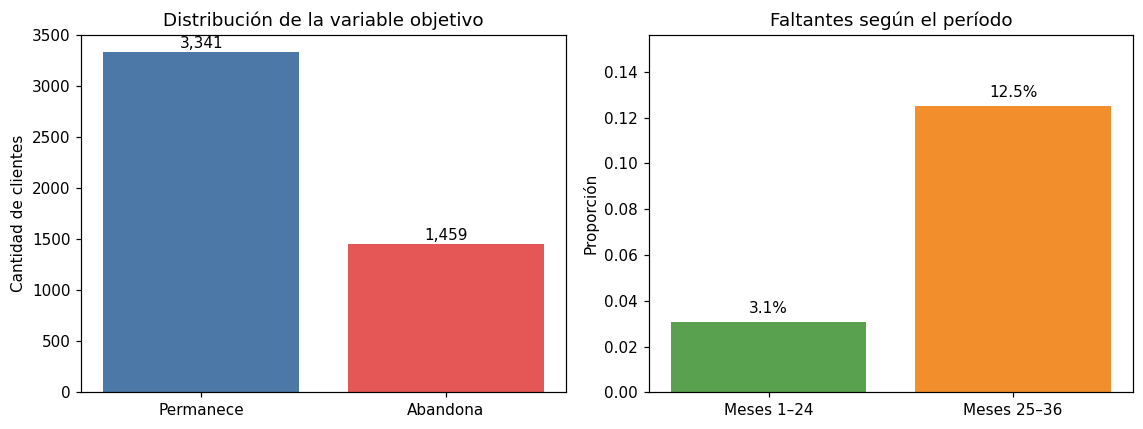

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4))

conteos = clientes["abandono"].value_counts().sort_index()
axes[0].bar(
    ["Permanece", "Abandona"],
    conteos.values,
    color=["#4C78A8", "#E45756"],
)
axes[0].set_title("Distribución de la variable objetivo")
axes[0].set_ylabel("Cantidad de clientes")
for i, valor in enumerate(conteos.values):
    axes[0].text(i, valor + 35, f"{valor:,}", ha="center")

faltantes_mes = (
    clientes.assign(
        periodo=np.where(clientes["mes"] <= 24, "Meses 1–24", "Meses 25–36")
    )
    .groupby("periodo")["cargo_mensual"]
    .apply(lambda s: s.isna().mean())
    .reindex(["Meses 1–24", "Meses 25–36"])
)
axes[1].bar(
    faltantes_mes.index,
    faltantes_mes.values,
    color=["#59A14F", "#F28E2B"],
)
axes[1].set_title("Faltantes según el período")
axes[1].set_ylabel("Proporción")
axes[1].set_ylim(0, max(faltantes_mes.values) * 1.25)
for i, valor in enumerate(faltantes_mes.values):
    axes[1].text(i, valor + 0.004, f"{valor:.1%}", ha="center")

plt.tight_layout()
plt.show()


La clase positiva es minoritaria y los faltantes no aparecen con la misma frecuencia en todo el período. Ambas observaciones afectan la comunicación: accuracy no bastará como métrica y el cambio en la calidad del registro deberá figurar entre las limitaciones.


## 5. Separar desarrollo y test final

Los meses 1 a 30 se usarán para desarrollar y comparar alternativas. Los meses 31 a 36 se reservarán como test final. Así, la evaluación representa mejor la pregunta “¿qué ocurriría con clientes de un período posterior?”.


In [5]:
desarrollo = clientes[clientes["mes"] <= 30].copy()
test_final = clientes[clientes["mes"] > 30].copy()

variables = [
    "antiguedad_meses",
    "cargo_mensual",
    "reclamos_6m",
    "tickets_soporte",
    "caida_uso_pct",
    "contrato",
    "canal",
]
objetivo = "abandono"

X_desarrollo = desarrollo[variables]
y_desarrollo = desarrollo[objetivo]
X_test = test_final[variables]
y_test = test_final[objetivo]

pd.DataFrame({
    "Conjunto": ["Desarrollo", "Test final"],
    "Casos": [len(desarrollo), len(test_final)],
    "Meses": ["1–30", "31–36"],
    "Proporción positiva": [y_desarrollo.mean(), y_test.mean()],
})


,Conjunto,Casos,Meses,Proporción positiva
0,Desarrollo,3962,1–30,0.304
1,Test final,838,31–36,0.303


## 6. Justificar el enfoque

Las variables numéricas se imputarán con la mediana. Las categóricas se imputarán con la categoría más frecuente y se codificarán mediante One-Hot Encoding. Todo quedará dentro de pipelines para que las transformaciones se aprendan únicamente con los datos de entrenamiento de cada fold.

Compararemos tres alternativas:

- una referencia que predice siempre la clase más frecuente;
- regresión logística como modelo simple e interpretable;
- Random Forest como modelo más flexible, capaz de representar relaciones no lineales.

La métrica principal será F1 para la clase de abandono, porque resume el equilibrio entre detectar abandonos y no producir demasiadas alertas incorrectas. También observaremos precision y recall por separado.


In [6]:
columnas_numericas = [
    "antiguedad_meses",
    "cargo_mensual",
    "reclamos_6m",
    "tickets_soporte",
    "caida_uso_pct",
]
columnas_categoricas = ["contrato", "canal"]

prep_numerico = Pipeline([
    ("imputar", SimpleImputer(strategy="median")),
    ("escalar", StandardScaler()),
])
prep_categorico = Pipeline([
    ("imputar", SimpleImputer(strategy="most_frequent")),
    ("codificar", OneHotEncoder(handle_unknown="ignore")),
])

preprocesamiento = ColumnTransformer([
    ("num", prep_numerico, columnas_numericas),
    ("cat", prep_categorico, columnas_categoricas),
])

modelos = {
    "Referencia": Pipeline([
        ("prep", preprocesamiento),
        ("modelo", DummyClassifier(strategy="most_frequent")),
    ]),
    "Regresión logística": Pipeline([
        ("prep", preprocesamiento),
        ("modelo", LogisticRegression(max_iter=2_000, random_state=31)),
    ]),
    "Random Forest": Pipeline([
        ("prep", preprocesamiento),
        ("modelo", RandomForestClassifier(
            n_estimators=350,
            min_samples_leaf=8,
            max_features="sqrt",
            class_weight="balanced",
            random_state=31,
            n_jobs=-1,
        )),
    ]),
}


## 7. Comparar modelos sin exagerar

Usaremos exactamente los mismos cinco folds estratificados para todos los modelos. Reportaremos promedio y desviación, no solo el valor más alto.


In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=31)
metricas = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
}

filas_cv = []
scores_por_modelo = {}

for nombre, pipeline in modelos.items():
    resultado = cross_validate(
        pipeline,
        X_desarrollo,
        y_desarrollo,
        cv=cv,
        scoring=metricas,
        n_jobs=-1,
    )
    scores_por_modelo[nombre] = resultado
    fila = {"Modelo": nombre}
    for metrica in metricas:
        valores = resultado[f"test_{metrica}"]
        fila[f"{metrica}_media"] = valores.mean()
        fila[f"{metrica}_desv"] = valores.std()
    filas_cv.append(fila)

comparacion_cv = pd.DataFrame(filas_cv).set_index("Modelo")
comparacion_cv


,accuracy_media,accuracy_desv,precision_media,precision_desv,recall_media,recall_desv,f1_media,f1_desv
Modelo,,,,,,,,
Referencia,0.696,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Regresión logística,0.790,0.011,0.702,0.023,0.540,0.033,0.610,0.026
Random Forest,0.764,0.008,0.595,0.013,0.699,0.020,0.643,0.011


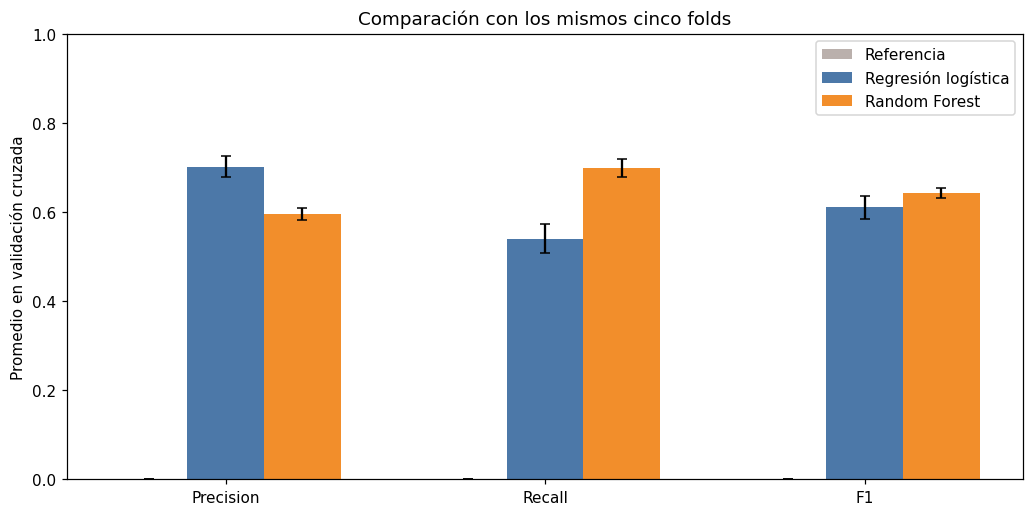

In [8]:
metricas_grafico = ["precision", "recall", "f1"]
modelos_grafico = list(modelos)
x = np.arange(len(metricas_grafico))
ancho = 0.24
colores = ["#BAB0AC", "#4C78A8", "#F28E2B"]

fig, ax = plt.subplots(figsize=(9.5, 4.8))
for i, nombre in enumerate(modelos_grafico):
    medias = [
        comparacion_cv.loc[nombre, f"{m}_media"]
        for m in metricas_grafico
    ]
    desvios = [
        comparacion_cv.loc[nombre, f"{m}_desv"]
        for m in metricas_grafico
    ]
    ax.bar(
        x + (i - 1) * ancho,
        medias,
        ancho,
        yerr=desvios,
        capsize=3,
        label=nombre,
        color=colores[i],
    )

ax.set_xticks(x, ["Precision", "Recall", "F1"])
ax.set_ylim(0, 1)
ax.set_ylabel("Promedio en validación cruzada")
ax.set_title("Comparación con los mismos cinco folds")
ax.legend()
plt.tight_layout()
plt.show()


Las barras de error representan la variabilidad entre folds. Una comunicación responsable no afirma que un modelo sea “el mejor en general”: describe cuál obtuvo el mayor resultado **en esta evaluación**, cuánto difiere de las alternativas y qué intercambio existe entre precision y recall.


In [9]:
estabilidad_f1 = pd.DataFrame({
    nombre: resultado["test_f1"]
    for nombre, resultado in scores_por_modelo.items()
})
estabilidad_f1.index = [f"Fold {i}" for i in range(1, 6)]
estabilidad_f1.loc["Promedio"] = estabilidad_f1.mean()
estabilidad_f1.loc["Desviación"] = estabilidad_f1.iloc[:5].std(ddof=0)
estabilidad_f1


,Referencia,Regresión logística,Random Forest
Fold 1,0.000,0.624,0.649
Fold 2,0.000,0.626,0.638
Fold 3,0.000,0.590,0.641
Fold 4,0.000,0.640,0.659
Fold 5,0.000,0.569,0.626
Promedio,0.000,0.610,0.643
Desviación,0.000,0.026,0.011


## 8. Elegir el procedimiento antes de mirar el test

La elección combinará el F1 promedio con la estabilidad y la posibilidad de explicar el modelo. La mejora numérica debe juzgarse en contexto: una diferencia muy pequeña no convierte automáticamente a un procedimiento más complejo en la única opción válida.


In [10]:
orden_f1 = comparacion_cv["f1_media"].sort_values(ascending=False)
modelo_elegido_nombre = orden_f1.index[0]
modelo_elegido = modelos[modelo_elegido_nombre]

print("Orden por F1 promedio:")
print(orden_f1.to_string())
print(f"\nProcedimiento elegido: {modelo_elegido_nombre}")


Orden por F1 promedio:
Modelo
Random Forest         0.643
Regresión logística   0.610
Referencia            0.000

Procedimiento elegido: Random Forest


El test final continúa sin utilizarse hasta este punto. Esta frase metodológica es importante en un informe: permite distinguir una comparación interna de una evaluación final.


## 9. Presentar métricas relevantes

Entrenaremos el procedimiento elegido con todo el conjunto de desarrollo y consultaremos una única vez los meses finales. Cada cifra se presentará junto con el conjunto donde fue calculada y con una interpretación ligada a la clase positiva.


In [11]:
modelo_elegido.fit(X_desarrollo, y_desarrollo)
pred_test = modelo_elegido.predict(X_test)
prob_test = modelo_elegido.predict_proba(X_test)[:, 1]

metricas_test = pd.Series({
    "Accuracy": accuracy_score(y_test, pred_test),
    "Precision": precision_score(y_test, pred_test, zero_division=0),
    "Recall": recall_score(y_test, pred_test, zero_division=0),
    "F1": f1_score(y_test, pred_test, zero_division=0),
}, name="Test final")
metricas_test.to_frame()


,Test final
Accuracy,0.773
Precision,0.619
Recall,0.654
F1,0.636


Verdaderos negativos: 482
Falsos positivos:     102
Falsos negativos:     88
Verdaderos positivos: 166


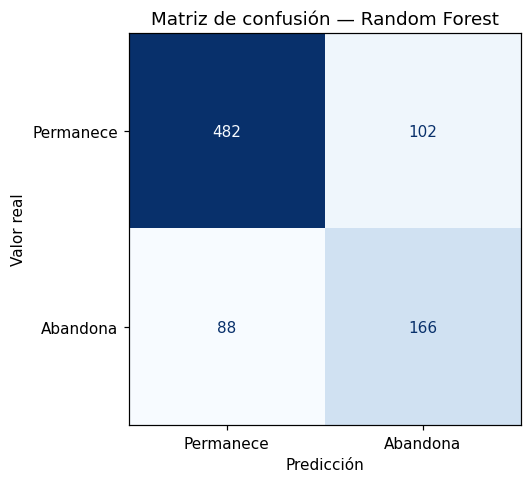

In [12]:
matriz = confusion_matrix(y_test, pred_test)
tn, fp, fn, tp = matriz.ravel()

fig, ax = plt.subplots(figsize=(5.2, 4.5))
ConfusionMatrixDisplay(
    matriz,
    display_labels=["Permanece", "Abandona"],
).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Matriz de confusión — {modelo_elegido_nombre}")
ax.set_xlabel("Predicción")
ax.set_ylabel("Valor real")
plt.tight_layout()
plt.show()

print(f"Verdaderos negativos: {tn}")
print(f"Falsos positivos:     {fp}")
print(f"Falsos negativos:     {fn}")
print(f"Verdaderos positivos: {tp}")


La matriz de confusión traduce las métricas a casos. Precision responde qué proporción de las alertas correspondió a abandonos reales; recall indica qué proporción de los abandonos reales fue detectada. Los falsos positivos implican contactos innecesarios y los falsos negativos representan abandonos que el sistema no habría priorizado.


## 10. El umbral también comunica una decisión

La probabilidad no se transforma inevitablemente en clase usando `0.50`. El umbral refleja qué intercambio estamos dispuestos a aceptar. Para mostrarlo, compararemos varios valores sin cambiar el modelo.


In [13]:
filas_umbral = []
for umbral in [0.30, 0.40, 0.50, 0.60, 0.70]:
    pred_umbral = (prob_test >= umbral).astype(int)
    filas_umbral.append({
        "Umbral": umbral,
        "Alertas": pred_umbral.sum(),
        "Precision": precision_score(
            y_test, pred_umbral, zero_division=0
        ),
        "Recall": recall_score(
            y_test, pred_umbral, zero_division=0
        ),
        "F1": f1_score(
            y_test, pred_umbral, zero_division=0
        ),
    })

tabla_umbrales = pd.DataFrame(filas_umbral)
tabla_umbrales


,Umbral,Alertas,Precision,Recall,F1
0,0.300,454,0.463,0.827,0.593
1,0.400,362,0.528,0.752,0.620
2,0.500,268,0.619,0.654,0.636
3,0.600,190,0.705,0.528,0.604
4,0.700,134,0.746,0.394,0.515


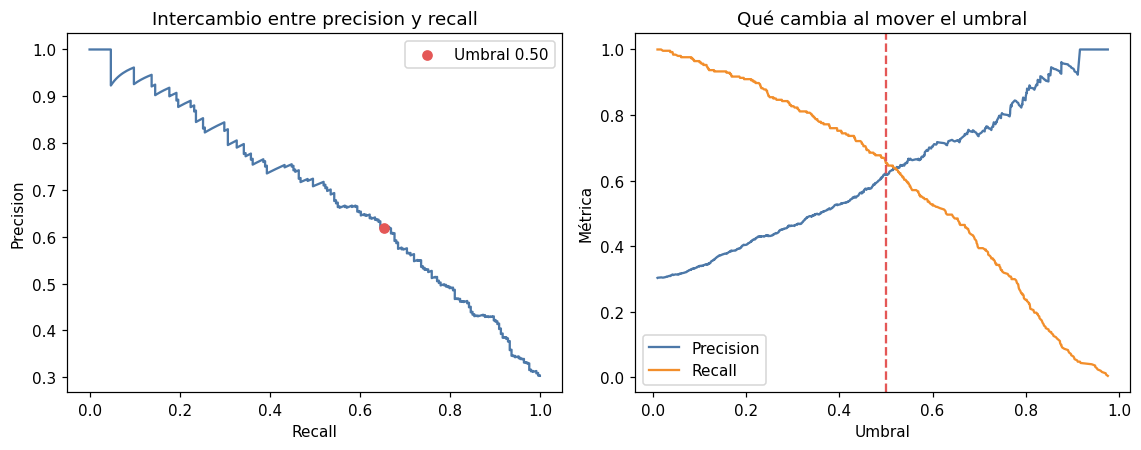

In [14]:
precision_curva, recall_curva, umbrales_curva = precision_recall_curve(
    y_test, prob_test
)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))

axes[0].plot(recall_curva, precision_curva, color="#4C78A8")
axes[0].scatter(
    metricas_test["Recall"],
    metricas_test["Precision"],
    color="#E45756",
    label="Umbral 0.50",
    zorder=3,
)
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Intercambio entre precision y recall")
axes[0].legend()

axes[1].plot(
    umbrales_curva,
    precision_curva[:-1],
    label="Precision",
    color="#4C78A8",
)
axes[1].plot(
    umbrales_curva,
    recall_curva[:-1],
    label="Recall",
    color="#F28E2B",
)
axes[1].axvline(0.50, color="#E45756", linestyle="--")
axes[1].set_xlabel("Umbral")
axes[1].set_ylabel("Métrica")
axes[1].set_title("Qué cambia al mover el umbral")
axes[1].legend()

plt.tight_layout()
plt.show()


Un umbral menor genera más alertas y suele aumentar recall, pero también puede reducir precision. El informe debería explicar quién revisará esas alertas, qué capacidad existe y qué error tiene mayor costo. El gráfico no decide el umbral por nosotros.


## 11. Mostrar errores y limitaciones

Una métrica global no revela si el modelo se comporta de manera similar en todos los grupos. Revisaremos los errores por tipo de contrato. `contrato` no se interpreta aquí como causa del abandono: solo permite describir asociaciones y detectar diferencias que merecen investigación.


In [15]:
revision = test_final[
    ["mes", "contrato", "canal", "abandono"]
].copy()
revision["prediccion"] = pred_test
revision["probabilidad"] = prob_test
revision["tipo_resultado"] = np.select(
    [
        (revision["abandono"] == 1) & (revision["prediccion"] == 1),
        (revision["abandono"] == 0) & (revision["prediccion"] == 1),
        (revision["abandono"] == 1) & (revision["prediccion"] == 0),
    ],
    ["Verdadero positivo", "Falso positivo", "Falso negativo"],
    default="Verdadero negativo",
)

revision.query(
    "tipo_resultado in ['Falso positivo', 'Falso negativo']"
).sort_values("probabilidad", ascending=False).head(12)


,mes,contrato,canal,abandono,prediccion,probabilidad,tipo_resultado
4338,33,Mensual,Movil,0,1,0.912,Falso positivo
4089,31,Mensual,Telefonico,0,1,0.876,Falso positivo
4284,33,Mensual,Web,0,1,0.853,Falso positivo
4504,34,Mensual,Web,0,1,0.849,Falso positivo
4496,34,Mensual,Movil,0,1,0.831,Falso positivo
4120,32,Mensual,Telefonico,0,1,0.825,Falso positivo
4536,35,Mensual,Movil,0,1,0.819,Falso positivo
4713,36,Mensual,Telefonico,0,1,0.807,Falso positivo
4501,34,Mensual,Web,0,1,0.802,Falso positivo
4391,33,Mensual,Movil,0,1,0.800,Falso positivo


In [16]:
filas_grupo = []
for contrato_valor, grupo in revision.groupby("contrato"):
    filas_grupo.append({
        "Contrato": contrato_valor,
        "Casos": len(grupo),
        "Abandono real": grupo["abandono"].mean(),
        "Precision": precision_score(
            grupo["abandono"], grupo["prediccion"], zero_division=0
        ),
        "Recall": recall_score(
            grupo["abandono"], grupo["prediccion"], zero_division=0
        ),
        "F1": f1_score(
            grupo["abandono"], grupo["prediccion"], zero_division=0
        ),
    })

metricas_contrato = (
    pd.DataFrame(filas_grupo)
    .sort_values("Contrato")
    .reset_index(drop=True)
)
metricas_contrato


,Contrato,Casos,Abandono real,Precision,Recall,F1
0,Anual,255,0.220,0.517,0.536,0.526
1,Bienal,112,0.188,0.474,0.429,0.450
2,Mensual,471,0.376,0.665,0.718,0.690


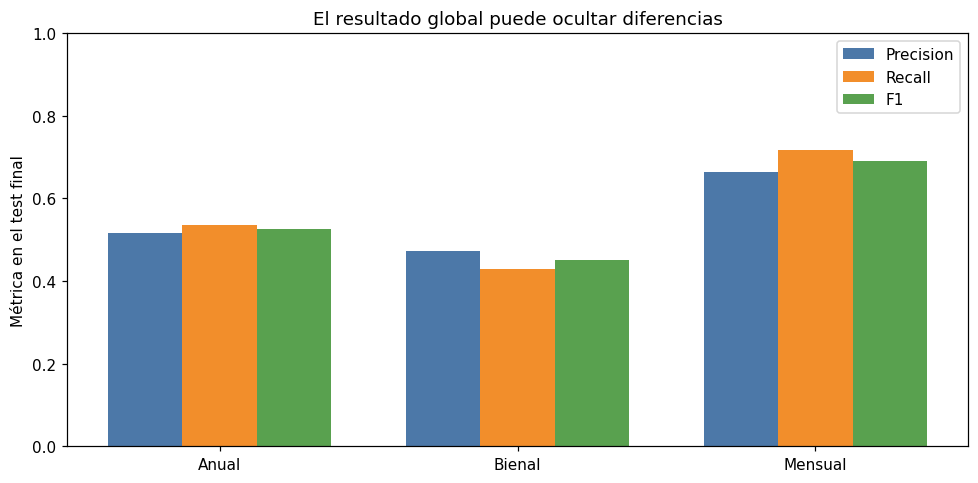

In [17]:
posiciones = np.arange(len(metricas_contrato))
ancho = 0.25

fig, ax = plt.subplots(figsize=(9, 4.5))
for i, (metrica, color) in enumerate([
    ("Precision", "#4C78A8"),
    ("Recall", "#F28E2B"),
    ("F1", "#59A14F"),
]):
    ax.bar(
        posiciones + (i - 1) * ancho,
        metricas_contrato[metrica],
        ancho,
        label=metrica,
        color=color,
    )

ax.set_xticks(posiciones, metricas_contrato["Contrato"])
ax.set_ylim(0, 1)
ax.set_ylabel("Métrica en el test final")
ax.set_title("El resultado global puede ocultar diferencias")
ax.legend()
plt.tight_layout()
plt.show()


Las métricas por contrato son descriptivas y se calculan sobre grupos de tamaños diferentes. Una diferencia no demuestra discriminación ni causalidad, pero sí evita afirmar que el rendimiento global representa por igual a todos los casos.


### Limitaciones que deben aparecer en el informe

- Los datos son sintéticos y sirven para practicar el procedimiento, no para conocer clientes reales.
- El test cubre solo seis meses y contiene más variabilidad que el período de desarrollo.
- Los faltantes de `cargo_mensual` aumentan con el tiempo.
- No se incorporaron todos los factores que podrían relacionarse con el abandono.
- El modelo identifica asociaciones predictivas; no demuestra por qué una persona abandona.
- Las métricas por subgrupo pueden ser inestables cuando hay pocos casos positivos.
- Antes de usar alertas reales habría que estudiar costos, capacidad de revisión, privacidad y posibles impactos desiguales.


## 12. De números aislados a afirmaciones completas

Comparemos tres maneras de redactar el mismo resultado:

| Redacción | Problema |
|---|---|
| “F1 = 0,70.” | No indica problema, clase ni conjunto |
| “El modelo predice correctamente el abandono.” | Convierte un resultado parcial en una certeza |
| “En el test temporal, el modelo obtuvo un F1 de 0,70 para abandono.” | Sitúa la métrica y evita generalizar |

Todavía podemos mejorar la tercera versión explicando precision, recall, errores y uso previsto.


In [18]:
afirmaciones = {
    "Incompleta": (
        f"El modelo obtuvo F1 = {metricas_test['F1']:.3f}."
    ),
    "Exagerada": (
        "El modelo identifica correctamente a los clientes "
        "que abandonarán."
    ),
    "Responsable": (
        f"En el test temporal de los meses 31 a 36, "
        f"{modelo_elegido_nombre} obtuvo F1 "
        f"{metricas_test['F1']:.3f} para la clase de abandono, "
        f"con precision {metricas_test['Precision']:.3f} y "
        f"recall {metricas_test['Recall']:.3f}. "
        "El resultado corresponde a este dataset sintético y "
        "debería interpretarse como apoyo para priorizar revisiones."
    ),
}

for tipo, texto in afirmaciones.items():
    print(f"{tipo.upper()}\n{texto}\n")


INCOMPLETA
El modelo obtuvo F1 = 0.636.

EXAGERADA
El modelo identifica correctamente a los clientes que abandonarán.

RESPONSABLE
En el test temporal de los meses 31 a 36, Random Forest obtuvo F1 0.636 para la clase de abandono, con precision 0.619 y recall 0.654. El resultado corresponde a este dataset sintético y debería interpretarse como apoyo para priorizar revisiones.



## 13. Escribir una conclusión responsable

La conclusión debe volver al objetivo, resumir el resultado, explicar los errores relevantes, reconocer límites y proponer un uso compatible con la evidencia. No debería presentar la probabilidad como certeza ni la asociación como causa.


In [19]:
tasa_fp = fp / (fp + tn)
tasa_fn = fn / (fn + tp)
mejor_f1_cv = comparacion_cv.loc[modelo_elegido_nombre, "f1_media"]
desv_f1_cv = comparacion_cv.loc[modelo_elegido_nombre, "f1_desv"]

conclusion = f'''
El objetivo fue anticipar qué clientes podrían abandonar el servicio
durante el mes siguiente, a partir de información disponible hasta la
fecha de corte. En validación cruzada sobre los meses 1 a 30,
{modelo_elegido_nombre} obtuvo un F1 promedio de {mejor_f1_cv:.3f}
(desviación {desv_f1_cv:.3f}).

Al evaluarlo una única vez sobre los meses 31 a 36, alcanzó un F1 de
{metricas_test['F1']:.3f}, con precision {metricas_test['Precision']:.3f}
y recall {metricas_test['Recall']:.3f}. El modelo dejó sin detectar
{fn} de los {fn + tp} abandonos y generó {fp} alertas sobre clientes
que permanecieron.

Los resultados sugieren que el procedimiento podría servir como apoyo
para priorizar casos, pero no justifican automatizar decisiones. Los
datos son sintéticos, el período final es breve, la calidad del registro
cambia con el tiempo y las diferencias observadas no demuestran
relaciones causales. Antes de una aplicación real sería necesario
validar con datos representativos, revisar impactos por subgrupo y
definir el umbral según costos y capacidad de seguimiento.
'''.strip()

print(conclusion)


El objetivo fue anticipar qué clientes podrían abandonar el servicio
durante el mes siguiente, a partir de información disponible hasta la
fecha de corte. En validación cruzada sobre los meses 1 a 30,
Random Forest obtuvo un F1 promedio de 0.643
(desviación 0.011).

Al evaluarlo una única vez sobre los meses 31 a 36, alcanzó un F1 de
0.636, con precision 0.619
y recall 0.654. El modelo dejó sin detectar
88 de los 254 abandonos y generó 102 alertas sobre clientes
que permanecieron.

Los resultados sugieren que el procedimiento podría servir como apoyo
para priorizar casos, pero no justifican automatizar decisiones. Los
datos son sintéticos, el período final es breve, la calidad del registro
cambia con el tiempo y las diferencias observadas no demuestran
relaciones causales. Antes de una aplicación real sería necesario
validar con datos representativos, revisar impactos por subgrupo y
definir el umbral según costos y capacidad de seguimiento.


La conclusión no oculta la caída o los errores. Tampoco invalida el trabajo: delimita para qué podría ser útil y qué evidencia todavía falta.


## 14. Un informe básico y reproducible

Podemos reunir los elementos esenciales en una ficha. La ficha no reemplaza un informe extenso, pero ayuda a verificar que ninguna parte importante haya quedado fuera.


In [20]:
ficha = pd.DataFrame([
    {
        "Sección": "Problema",
        "Contenido": (
            "Anticipar abandono durante el mes siguiente para "
            "priorizar revisiones."
        ),
    },
    {
        "Sección": "Datos",
        "Contenido": (
            f"{len(clientes):,} clientes sintéticos; meses 1–36; "
            f"{clientes['abandono'].mean():.1%} de clase positiva."
        ),
    },
    {
        "Sección": "Enfoque",
        "Contenido": (
            "Pipelines con imputación, escalado y One-Hot Encoding; "
            "comparación en cinco folds."
        ),
    },
    {
        "Sección": "Modelo elegido",
        "Contenido": modelo_elegido_nombre,
    },
    {
        "Sección": "Resultado final",
        "Contenido": (
            f"F1 {metricas_test['F1']:.3f}; "
            f"precision {metricas_test['Precision']:.3f}; "
            f"recall {metricas_test['Recall']:.3f}."
        ),
    },
    {
        "Sección": "Errores",
        "Contenido": f"{fp} falsos positivos y {fn} falsos negativos.",
    },
    {
        "Sección": "Limitaciones",
        "Contenido": (
            "Datos sintéticos, test breve, cambio temporal, faltantes "
            "crecientes y ausencia de inferencia causal."
        ),
    },
    {
        "Sección": "Uso prudente",
        "Contenido": (
            "Apoyo para priorizar casos; requiere revisión humana."
        ),
    },
])

pd.set_option("display.max_colwidth", 110)
ficha


,Sección,Contenido
0,Problema,Anticipar abandono durante el mes siguiente para priorizar revisiones.
1,Datos,"4,800 clientes sintéticos; meses 1–36; 30.4% de clase positiva."
2,Enfoque,"Pipelines con imputación, escalado y One-Hot Encoding; comparación en cinco folds."
3,Modelo elegido,Random Forest
4,Resultado final,F1 0.636; precision 0.619; recall 0.654.
5,Errores,102 falsos positivos y 88 falsos negativos.
6,Limitaciones,"Datos sintéticos, test breve, cambio temporal, faltantes crecientes y ausencia de inferencia causal."
7,Uso prudente,Apoyo para priorizar casos; requiere revisión humana.


## 15. Adaptar el mensaje al público

El resultado técnico es el mismo, pero no todas las personas necesitan el mismo nivel de detalle.

- Un equipo técnico necesita conocer particiones, pipeline, hiperparámetros, métricas por fold y limitaciones del diseño.
- Un equipo de gestión necesita entender el objetivo, la cantidad de alertas, los tipos de error, el posible uso y los riesgos.
- Una persona afectada por una decisión necesita una explicación clara del propósito, los datos relevantes y la posibilidad de revisión.

Simplificar el lenguaje no significa esconder incertidumbre ni borrar limitaciones.


In [21]:
mensaje_tecnico = (
    f"Pipeline {modelo_elegido_nombre}; CV estratificada de 5 folds "
    f"sobre meses 1–30; F1 medio {mejor_f1_cv:.3f} ± "
    f"{desv_f1_cv:.3f}. Test temporal meses 31–36: "
    f"F1 {metricas_test['F1']:.3f}, "
    f"precision {metricas_test['Precision']:.3f}, "
    f"recall {metricas_test['Recall']:.3f}."
)

mensaje_gestion = (
    f"El modelo detectó {tp} de {tp + fn} abandonos del período final "
    f"y generó {fp} alertas innecesarias. Puede ayudar a ordenar "
    "casos para revisión, pero no reemplaza el criterio humano."
)

print("PARA UN EQUIPO TÉCNICO")
print(mensaje_tecnico)
print("\nPARA UN EQUIPO DE GESTIÓN")
print(mensaje_gestion)


PARA UN EQUIPO TÉCNICO
Pipeline Random Forest; CV estratificada de 5 folds sobre meses 1–30; F1 medio 0.643 ± 0.011. Test temporal meses 31–36: F1 0.636, precision 0.619, recall 0.654.

PARA UN EQUIPO DE GESTIÓN
El modelo detectó 166 de 254 abandonos del período final y generó 102 alertas innecesarias. Puede ayudar a ordenar casos para revisión, pero no reemplaza el criterio humano.


## 16. Actividad modificable

Imaginemos que el equipo solo puede revisar una proporción limitada de clientes. Modificá `capacidad_revision` y observá qué umbral selecciona el código, cuántas alertas genera y qué precision y recall consigue.

La actividad no busca un umbral universal. Su objetivo es mostrar que una decisión operativa cambia la forma en que debe comunicarse el rendimiento.


In [22]:
capacidad_revision = 0.20  # Probá, por ejemplo, 0.10, 0.25 o 0.35

cantidad_alertas = max(1, int(len(prob_test) * capacidad_revision))
orden = np.argsort(prob_test)[::-1]
seleccionados = orden[:cantidad_alertas]

pred_capacidad = np.zeros(len(prob_test), dtype=int)
pred_capacidad[seleccionados] = 1
umbral_capacidad = prob_test[seleccionados].min()

resultado_capacidad = pd.Series({
    "Capacidad de revisión": capacidad_revision,
    "Clientes revisados": pred_capacidad.sum(),
    "Umbral resultante": umbral_capacidad,
    "Precision": precision_score(
        y_test, pred_capacidad, zero_division=0
    ),
    "Recall": recall_score(
        y_test, pred_capacidad, zero_division=0
    ),
    "F1": f1_score(
        y_test, pred_capacidad, zero_division=0
    ),
})
resultado_capacidad.to_frame("Resultado")


,Resultado
Capacidad de revisión,0.200
Clientes revisados,167.000
Umbral resultante,0.658
Precision,0.719
Recall,0.472
F1,0.570


Una redacción adecuada para esta actividad debería incluir la capacidad elegida, la cantidad de clientes priorizados, los abandonos detectados y las alertas incorrectas. Decir solamente “el umbral óptimo es…” ocultaría que el valor depende de una restricción concreta.


## 17. Lista de revisión del informe

Antes de entregar una comunicación de resultados, conviene comprobar:

1. ¿El problema aparece antes que el nombre del algoritmo?
2. ¿Se explica qué representa cada fila, la clase positiva y el momento de predicción?
3. ¿Las decisiones metodológicas están justificadas?
4. ¿Cada métrica indica qué mide y sobre qué datos se calculó?
5. ¿La comparación considera variabilidad y no solo el mayor número?
6. ¿Se muestran falsos positivos, falsos negativos y grupos relevantes?
7. ¿Las limitaciones de los datos y de la evaluación son visibles?
8. ¿Se evita confundir predicción con causalidad?
9. ¿La conclusión aclara el uso previsto y la necesidad de revisión?
10. ¿El lenguaje está adaptado al público sin ocultar incertidumbre?


## 18. Síntesis

Comunicar un proyecto de Machine Learning no consiste en pegar gráficos y métricas al final de un cuaderno. En este caso partimos de una pregunta concreta, describimos la evidencia disponible, justificamos el procedimiento, comparamos alternativas bajo las mismas condiciones y reservamos un período final para evaluar.

Después convertimos los resultados en significados: cuántos abandonos se detectaron, cuántas alertas incorrectas aparecieron, qué cambia con el umbral y dónde el rendimiento no es uniforme. Finalmente, redactamos una conclusión que reconoce datos sintéticos, cambio temporal, faltantes y ausencia de causalidad.

Un buen informe permite entender tanto lo que el modelo sugiere como lo que todavía no puede sostenerse.


## Para pensar

1. ¿Qué información falta cuando un informe solo dice “el modelo obtuvo F1 = 0,80”?
2. ¿Cómo cambiaría el mensaje si el costo principal fuera contactar clientes innecesariamente?
3. ¿Por qué una diferencia entre métricas de dos grupos no demuestra por sí sola una causa?
4. ¿Qué detalles conservarías en un informe técnico y cuáles traducirías para un público general?
5. ¿Cómo reescribirías la frase “el modelo sabe qué clientes abandonarán” de manera responsable?


---

### Autoría y atribución

Este cuaderno forma parte del material educativo desarrollado por **VintaBytes**.

📧 **Contacto:** [vintabytes@gmail.com](mailto:vintabytes@gmail.com)

🌐 **Repositorio oficial:** [github.com/VintaBytes/Ciencia-de-datos](https://github.com/VintaBytes/Ciencia-de-datos)

Se permite compartir y reutilizar este material respetando la autoría y manteniendo visible esta atribución.

---
